# Figure 2 Reproduction

This notebook reproduces Figure 2 from the paper using pre-processed CSV data.



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import string
from pathlib import Path

# --- Configuration ---
MODEL_COLORS = {
    "EEGNetv4": "#f4a582",
    "ATCNet": "#92c5de",
    "ShallowConvNet": "#ca0020",
    "DeepConvNet": "#0571b0",
}

DATASETS_ORDER = ["Yang2025", "BI2015a", "Lee2019_SSVEP"]
DATASET_LABELS = {
    "Yang2025": "MI (Yang2025)",
    "BI2015a": "P300 (BI2015a)",
    "Lee2019_SSVEP": "SSVEP (Lee2019)",
}

DATASET_TRIAL_CUTOFFS = {
    "Yang2025": 600,
    "BI2015a": 1044,
    "Lee2019_SSVEP": 200,
}

# configurable y-axis limits for each row
# row 0 = time series (top), row 1 = scatter plots (bottom)
# set to None to use data-driven limits
ROW_Y_LIMITS = {
    "time_series": None,  # top row: time series plots
    "scatter": (0.45, 1.0),  # bottom row: scatter plots
}

FONTSIZE = 7

In [7]:
# Load data
data_dir = Path("figure_data")
time_series_df = pd.read_csv(data_dir / "figure2_time_series_data.csv.gz")
scatter_df = pd.read_csv(data_dir / "figure2_scatter_data.csv")

print(f"Time series data shape: {time_series_df.shape}")
print(f"Scatter data shape: {scatter_df.shape}")
print(f"\nDatasets in time series: {sorted(time_series_df['dataset'].unique())}")
print(f"Methods in time series: {sorted(time_series_df['method'].unique())}")
print(f"Models in time series: {sorted(time_series_df['model'].unique())}")

Time series data shape: (22128, 7)
Scatter data shape: (592, 7)

Datasets in time series: ['BI2015a', 'Lee2019_SSVEP', 'Yang2025']
Methods in time series: ['CFT-only', 'PRE+CFT', 'PRE-ZS']
Models in time series: ['ATCNet', 'DeepConvNet', 'EEGNetv4', 'ShallowConvNet']


In [8]:
def plot_time_series(
    ax,
    dataset,
    cutoff,
    show_xlabel=False,
    show_ylabel=False,
    show_legend=False,
    y_limits=None,
):
    """Plot time series for a single dataset."""
    data = time_series_df[time_series_df["dataset"] == dataset]

    for model in MODEL_COLORS.keys():
        model_data = data[data["model"] == model]
        color = MODEL_COLORS[model]

        # Plot PRE+CFT (solid line)
        cft_data = model_data[model_data["method"] == "PRE+CFT"].sort_values(
            "trial_index"
        )
        if not cft_data.empty:
            ax.plot(
                cft_data["trial_index"],
                cft_data["smoothed_accuracy"],
                color=color,
                linewidth=2,
                linestyle="-",
            )

        # Plot PRE-ZS (dotted line)
        zs_data = model_data[model_data["method"] == "PRE-ZS"].sort_values(
            "trial_index"
        )
        if not zs_data.empty:
            ax.plot(
                zs_data["trial_index"],
                zs_data["smoothed_accuracy"],
                color=color,
                linewidth=2,
                linestyle="dotted",
            )

    # Formatting
    ax.set_xlim(0, cutoff)
    if y_limits is not None:
        ax.set_ylim(y_limits)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_xlabel:
        ax.set_xlabel("Trial index", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("Smoothed mean bal. acc.", fontsize=FONTSIZE)

    # Tick formatting (matched to fig_2.py)
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:0.2f}"))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:0.0f}"))
    ax.tick_params(axis="both", labelsize=FONTSIZE)

    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            Line2D([0], [0], color="black", lw=2, label="PRE+CFT", linestyle="-"),
            Line2D([0], [0], color="black", lw=2, label="PRE-ZS", linestyle="dotted"),
        ]
        ax.legend(
            handles=legend_elements, loc="lower right", fontsize=FONTSIZE, frameon=False
        )

In [9]:
def plot_scatter(
    ax,
    dataset,
    show_xlabel=False,
    show_ylabel=False,
    show_legend=False,
    axis_limits=None,
):
    """Plot scatter plot for a single dataset."""
    data = scatter_df[scatter_df["dataset"] == dataset].copy()
    data = data.dropna(subset=["PRE-ZS", "PRE+CFT"])

    # axis limits for consistent scaling across panels
    if axis_limits is not None:
        plot_min, plot_max = axis_limits
    else:
        plot_min, plot_max = 0.45, 1.0

    handles = []
    for model in MODEL_COLORS.keys():
        model_data = data[data["model"] == model]
        if not model_data.empty:
            # separate normal points from outliers (below plot_min)
            normal_mask = (model_data["PRE-ZS"] >= plot_min) & (
                model_data["PRE+CFT"] >= plot_min
            )
            normal_data = model_data[normal_mask]
            outlier_data = model_data[~normal_mask]

            # plot normal points
            if not normal_data.empty:
                scatter = ax.scatter(
                    normal_data["PRE-ZS"],
                    normal_data["PRE+CFT"],
                    color=MODEL_COLORS[model],
                    s=8,
                    alpha=1,
                    edgecolors="k",
                    linewidths=0.1,
                    label=model,
                )
                handles.append(scatter)

            # add arrow annotations for outliers near axis edge
            for _, row in outlier_data.iterrows():
                x_val = max(row["PRE-ZS"], plot_min + 0.01)
                y_val = max(row["PRE+CFT"], plot_min + 0.01)
                # arrow pointing left toward actual x location
                ax.annotate(
                    "",
                    xy=(plot_min + 0.005, y_val),
                    xytext=(plot_min + 0.04, y_val),
                    arrowprops=dict(
                        arrowstyle="->",
                        color=MODEL_COLORS[model],
                        lw=1.0,
                        shrinkA=0,
                        shrinkB=0,
                    ),
                )

    ax.set_aspect("equal")
    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)

    # Add diagonal line and shading (matched to fig_2.py)
    lims = ax.get_xlim()
    ax.plot(lims, lims, "k--", alpha=0.6, linewidth=0.7, zorder=0)
    x_coords = np.linspace(lims[0], lims[1], 100)
    ax.fill_between(x_coords, x_coords, lims[1], color="green", alpha=0.05, zorder=0)
    ax.fill_between(x_coords, lims[0], x_coords, color="red", alpha=0.05, zorder=0)

    # Formatting (matched to fig_2.py)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_xlabel:
        ax.set_xlabel("PRE-ZS subject mean bal. acc.", fontsize=FONTSIZE)
    if show_ylabel:
        ax.set_ylabel("PRE+CFT subject mean bal. acc.", fontsize=FONTSIZE)

    # Tick formatting (matched to fig_2.py)
    ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:0.2f}"))
    ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=3))
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:0.2f}"))
    ax.tick_params(axis="both", labelsize=FONTSIZE)

    if show_legend:
        ax.legend(handles=handles, fontsize=FONTSIZE, frameon=False, loc="best")

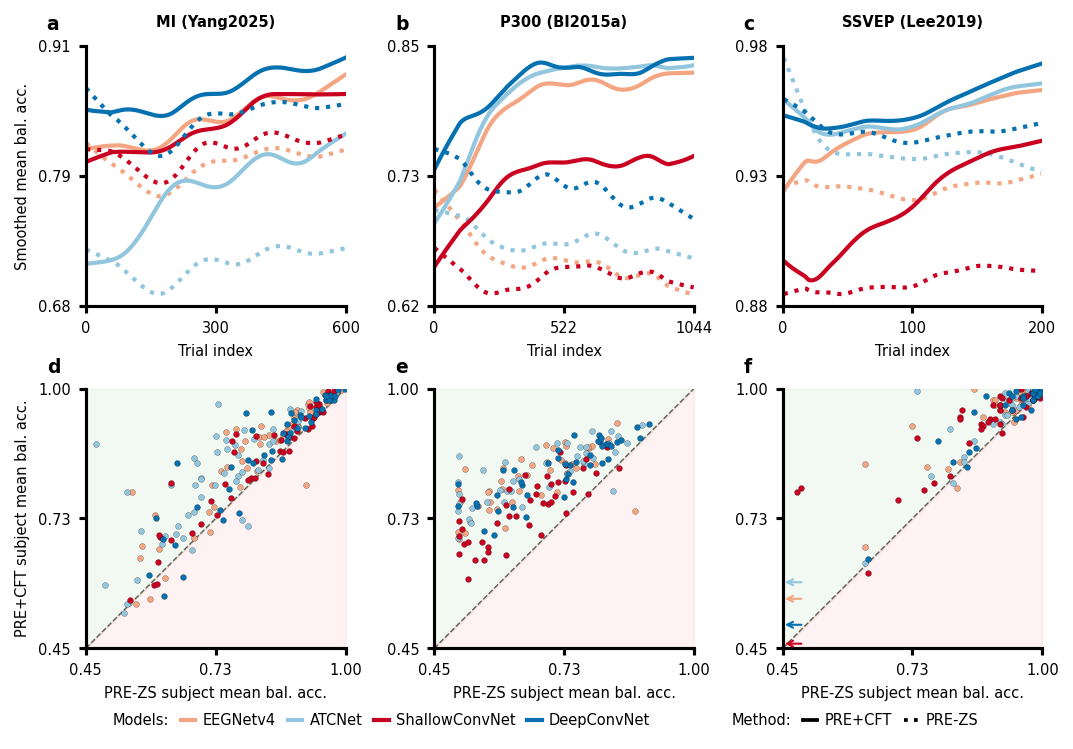

In [10]:
# --- Figure Layout and Style Configuration (from fig_2.py) ---
MAX_TOTAL_WIDTH_MM = 180.0
MARGIN_LEFT_CM = 1.4
MARGIN_RIGHT_CM = 0.4
MARGIN_TOP_CM = 0.8
MARGIN_BOTTOM_CM = 1.7
SPACING_HORIZONTAL_CM = 1.5
SPACING_VERTICAL_CM = 1.4
NUM_COLS = 3
NUM_ROWS = 2

# Calculate figure and panel dimensions
total_width_cm = MAX_TOTAL_WIDTH_MM / 10.0
effective_width_cm = total_width_cm - MARGIN_LEFT_CM - MARGIN_RIGHT_CM
panel_width_cm = (
    effective_width_cm - (NUM_COLS - 1) * SPACING_HORIZONTAL_CM
) / NUM_COLS
panel_height_cm = panel_width_cm  # Keep panels square

effective_height_cm = NUM_ROWS * panel_height_cm + (NUM_ROWS - 1) * SPACING_VERTICAL_CM
total_height_cm = effective_height_cm + MARGIN_BOTTOM_CM + MARGIN_TOP_CM

# Convert to inches for matplotlib
total_width_inches = total_width_cm / 2.54
total_height_inches = total_height_cm / 2.54

# --- Create the figure ---
fig, axes = plt.subplots(
    NUM_ROWS, NUM_COLS, figsize=(total_width_inches, total_height_inches), squeeze=False
)

panel_labels = list(string.ascii_lowercase)

# Plot time series (top row)
for col, dataset in enumerate(DATASETS_ORDER):
    ax = axes[0, col]
    ax.text(
        -0.15,
        1.12,
        panel_labels[col],
        transform=ax.transAxes,
        fontsize=FONTSIZE + 2,
        fontweight="bold",
        va="top",
        ha="left",
    )
    ax.set_title(DATASET_LABELS[dataset], fontsize=FONTSIZE, weight="bold", y=1.025)
    plot_time_series(
        ax,
        dataset,
        cutoff=DATASET_TRIAL_CUTOFFS[dataset],
        show_xlabel=True,
        show_ylabel=(col == 0),
        show_legend=False,
        y_limits=ROW_Y_LIMITS.get("time_series"),
    )

# Plot scatter plots (bottom row)
for col, dataset in enumerate(DATASETS_ORDER):
    ax = axes[1, col]
    ax.text(
        -0.15,
        1.12,
        panel_labels[col + NUM_COLS],
        transform=ax.transAxes,
        fontsize=FONTSIZE + 2,
        fontweight="bold",
        va="top",
        ha="left",
    )
    plot_scatter(
        ax,
        dataset,
        show_xlabel=True,
        show_ylabel=(col == 0),
        show_legend=False,
        axis_limits=ROW_Y_LIMITS.get("scatter"),
    )

# --- Add legends at the bottom (from fig_2.py) ---
from matplotlib.lines import Line2D

model_elements = [
    Line2D([0], [0], color=color, label=model, linewidth=2)
    for model, color in MODEL_COLORS.items()
]
method_elements = [
    Line2D([0], [0], color="black", lw=1.8, label="PRE+CFT", linestyle="-"),
    Line2D([0], [0], color="black", lw=1.8, label="PRE-ZS", linestyle="dotted"),
]
models_title = mpatches.Patch(color="none", label="Models:")
spacer = mpatches.Patch(color="none", label="   ")
method_title = mpatches.Patch(color="none", label="Method:")
all_handles = (
    [models_title] + model_elements + [spacer] + [method_title] + method_elements
)

fig.legend(
    handles=all_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(all_handles),
    frameon=False,
    fontsize=FONTSIZE,
    handletextpad=0.5,
    columnspacing=0.8,
    handlelength=1.0,
)

# --- Adjust layout (from fig_2.py) ---
left_norm = MARGIN_LEFT_CM / total_width_cm
right_norm = 1 - (MARGIN_RIGHT_CM / total_width_cm)
bottom_norm = MARGIN_BOTTOM_CM / total_height_cm
top_norm = 1 - (MARGIN_TOP_CM / total_height_cm)
wspace_val = SPACING_HORIZONTAL_CM / panel_width_cm if panel_width_cm > 0 else 0.1
hspace_val = SPACING_VERTICAL_CM / panel_height_cm if panel_height_cm > 0 else 0.1

fig.subplots_adjust(
    left=left_norm,
    right=right_norm,
    bottom=bottom_norm,
    top=top_norm,
    wspace=wspace_val,
    hspace=hspace_val,
)

# Save and show figure
plt.savefig("figure2.pdf", dpi=300)
plt.show()

In [11]:
# Display summary statistics
print("Data Summary:")
print("=" * 50)

print("\nTime Series Data Points per Dataset:")
for dataset in DATASETS_ORDER:
    count = len(time_series_df[time_series_df["dataset"] == dataset])
    print(f"  {DATASET_LABELS[dataset]}: {count} data points")

print("\nScatter Plot Subjects per Dataset:")
for dataset in DATASETS_ORDER:
    dataset_data = scatter_df[scatter_df["dataset"] == dataset]
    # Count subjects with both PRE-ZS and PRE+CFT data
    complete_subjects = dataset_data.dropna(subset=["PRE-ZS", "PRE+CFT"])
    n_subjects = len(complete_subjects)
    print(f"  {DATASET_LABELS[dataset]}: {n_subjects} subjects")

print("\nMean Performance Comparison:")
for dataset in DATASETS_ORDER:
    dataset_data = scatter_df[scatter_df["dataset"] == dataset].dropna(
        subset=["PRE-ZS", "PRE+CFT"]
    )
    if not dataset_data.empty:
        mean_zs = dataset_data["PRE-ZS"].mean()
        mean_cft = dataset_data["PRE+CFT"].mean()
        improvement = mean_cft - mean_zs
        print(f"  {DATASET_LABELS[dataset]}:")
        print(f"    PRE-ZS: {mean_zs:.3f}")
        print(f"    PRE+CFT: {mean_cft:.3f}")
        print(f"    Improvement: {improvement:+.3f}")

Data Summary:

Time Series Data Points per Dataset:
  MI (Yang2025): 7200 data points
  P300 (BI2015a): 12528 data points
  SSVEP (Lee2019): 2400 data points

Scatter Plot Subjects per Dataset:
  MI (Yang2025): 204 subjects
  P300 (BI2015a): 172 subjects
  SSVEP (Lee2019): 216 subjects

Mean Performance Comparison:
  MI (Yang2025):
    PRE-ZS: 0.799
    PRE+CFT: 0.845
    Improvement: +0.046
  P300 (BI2015a):
    PRE-ZS: 0.672
    PRE+CFT: 0.801
    Improvement: +0.129
  SSVEP (Lee2019):
    PRE-ZS: 0.924
    PRE+CFT: 0.950
    Improvement: +0.026
